In [1]:
import numpy as np
import znnl as nl

import pandas as pd

from flax import linen as nn
import optax

import matplotlib.pyplot as plt
from neural_tangents import stax

import h5py as hf
from scipy.stats import pearsonr

from rich.progress import track

import seaborn as sns

Using backend: cpu

Available hardware:

TFRT_CPU_0

## Download the data

In [2]:
class AbaloneData(nl.data.DataGenerator):
    """
    Generator for the Abalone data-set.
    
    Notes
    -----
    
    URL: http://archive.ics.uci.edu/static/public/1/abalone.zip
    """
    
    def __init__(self, data_file: str = "abalone.data"):
        """
        Build the data-set.
        """
        self.data_file = data_file
        self.columns = [
            "Sex",
            "Length", 
            "Diameter", 
            "Height", 
            "Whole weight", 
            "Shucked weight", 
            "Viscera weight", 
            "Shell weight", 
            "Rings"
        ]
        
        # Collect the processed data
        processed_data = self._process_raw_data()
        
        # Create the data-sets
        train_ds = processed_data.sample(frac=0.8, random_state=0)
        train_labels = train_ds.pop("Rings")
        
        test_ds = processed_data.drop(train_ds.index)
        test_labels = test_ds.pop("Rings")
        
        self.train_ds = {
            "inputs": train_ds.to_numpy(), 
            "targets": train_labels.to_numpy().reshape(-1, 1)
        }
        self.test_ds = {
            "inputs": test_ds.to_numpy(), 
            "targets": test_labels.to_numpy().reshape(-1, 1)
        }
        
        self.data_pool = self.train_ds["inputs"]
        
        
    def _process_raw_data(self):
        """
        Process the raw data
        """
        # Process the raw data.
        raw_data = pd.read_csv(
            self.data_file, names=self.columns, na_values='?', comment='#',
                          sep=',', skipinitialspace=True
        )
        raw_data.dropna()
        
        # encode the sex data
        raw_data = pd.get_dummies(raw_data, columns=['Sex'], prefix='', prefix_sep='')
        # Normalize
        raw_data = (raw_data - raw_data.mean()) / raw_data.std()

        return raw_data
        
        

In [3]:
generator = AbaloneData()

In [26]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 0.9, 1.0, 1.1]
ensembles = 5

data = {item: [] for item in alphas}

for item in alphas:
    for _ in range(ensembles):
        network = stax.serial(
            stax.Dense(128),
            stax.Relu(),
            stax.Dense(128),
            stax.Relu(),
            stax.Dense(1),
        )

        optimizer = nl.optimizers.TraceOptimizer(
            scale_factor=item, subset=0.1, 
        )

        model = nl.models.NTModel(
                nt_module=network,
                optimizer=optimizer,
                input_shape=(1, 10),
        )
        training_strategy = nl.training_strategies.SimpleTraining(
            model=model, 
            loss_fn=nl.loss_functions.MeanPowerLoss(order=2),
        )
        data[item].append(
            training_strategy.train_model(
                train_ds=generator.train_ds,
                test_ds=generator.test_ds, 
                epochs=50, 
                batch_size=128
            )["train_losses"]
        )

Epoch: 50: 100%|████████████████████████████████| 50/50 [00:17<00:00,  2.85batch/s, test_loss=0.527]


In [28]:
data[1.1] = [data[1.1][2], data[1.1][3], data[1.1][4]]
data[1.0] = [data[1.0][0], data[1.0][1], data[1.0][2], data[1.0][4]]
data[0.9] = [data[0.9][0], data[0.9][1], data[0.9][2], data[0.9][4]]

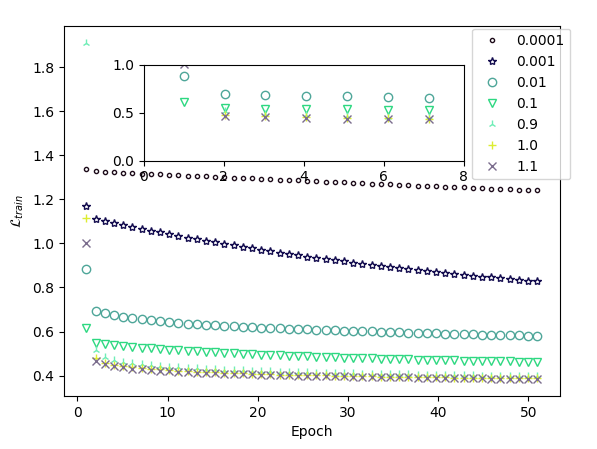

In [67]:
x_data = np.linspace(1, 51, 50)

marker_list = [".", "*", "o", "v", "2", "+", "x"]
color = [
    "#1C0B19", "#140D4F", "#4EA699", "#2DD881", "#6FEDB7", "#DCED31", "#7B6D8D"
]


fig, ax1 = plt.subplots()

# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.25, 0.6, 0.5, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])


for i, item in enumerate(data):
    ax1.plot(
        x_data, 
        np.mean(data[item], axis=0),
#         yerr = np.std(data[item], axis=0),
        marker=marker_list[i],
        mfc="none",
        c=color[i],
        linestyle="none",
        label=item
    )
    ax2.plot(
        x_data, 
        np.mean(data[item], axis=0),
#         yerr = np.std(data[item], axis=0),
        marker=marker_list[i],
        mfc="none",
        c=color[i],
        linestyle="none",
    )
    
    
ax2.set_xlim(0, 8)
ax2.set_ylim(0.0, 1.0)

ax1.set_xlabel("Epoch")
ax1.set_ylabel(r"$\mathcal{L}_{train}$")
fig.legend(loc=(.79, .6))
plt.savefig("abalone-alpha-opt.pdf")
plt.show()